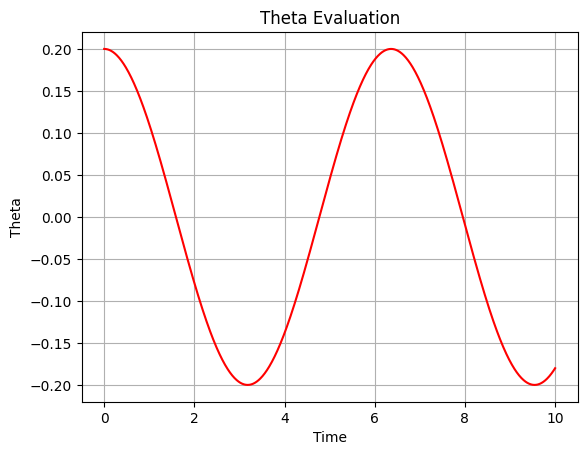

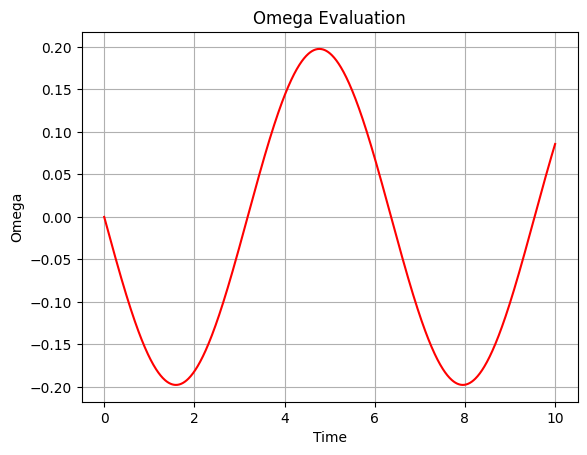

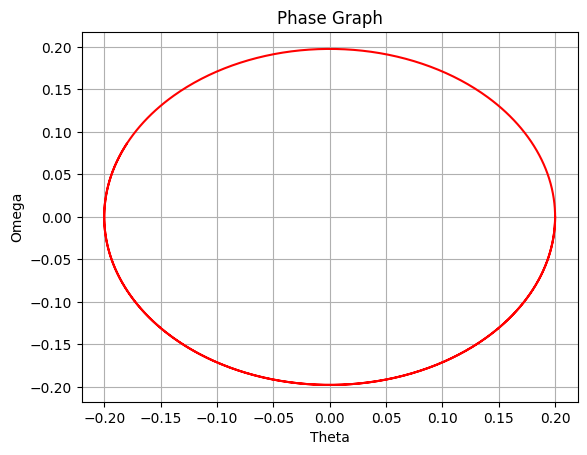

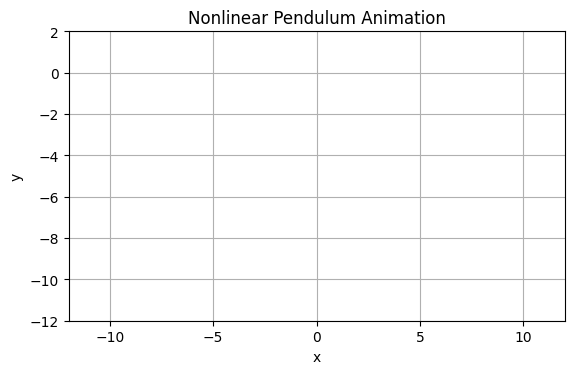

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# How to solve d^2theta/dt^2 = -g/l*sin(theta)
# We can use RK4 with:
# dtheta/dt = omega    dx/dt = f(x,y,t)  x(0) = x0
# domega/dt = -g/l*sin(theta)    dy/dt = g(x,y,t)  y(0) = y0

g = 9.8
l = 10.0
theta0 = 0.2
omega0 = 0.0
theta = theta0
omega = omega0
t = 0.0
dt = 0.01
steps = 1000

theta_RK4 = []; theta_RK4.append(theta)
omega_RK4 = []; omega_RK4.append(omega)
time = []; time.append(t)

def ftheta(theta,omega,t):
    return omega

def gomega(theta,omega,t):
    return -g/l*np.sin(theta)

def RK4(theta,omega,t):
    k1 = ftheta(theta,omega,t)
    l1 = gomega(theta,omega,t)
    k2 = ftheta(theta+k1*dt/2,omega+l1*dt/2,t)
    l2 = gomega(theta+k1*dt/2,omega+l1*dt/2,t)
    k3 = ftheta(theta+k2*dt/2,omega+l2*dt/2,t)
    l3 = gomega(theta+k2*dt/2,omega+l2*dt/2,t)
    k4 = ftheta(theta+k3*dt,omega+l3*dt,t)
    l4 = gomega(theta+k3*dt,omega+l3*dt,t)
    k_avg = (k1+2*k2+2*k3+k4)/6
    l_avg = (l1+2*l2+2*l3+l4)/6
    theta += k_avg*dt
    omega += l_avg*dt
    return theta,omega


for i in range(steps):
    theta,omega = RK4(theta,omega,t)
    t += dt

    theta_RK4.append(theta)
    omega_RK4.append(omega)
    time.append(t)

plt.plot(time, theta_RK4, 'r-', label='The evaluation of theta with time')
plt.xlabel('Time')
plt.ylabel('Theta')
plt.title('Theta Evaluation')
plt.grid()
plt.show()

plt.plot(time, omega_RK4, 'r-', label='The evaluation of omega with time')
plt.xlabel('Time')
plt.ylabel('Omega')
plt.title('Omega Evaluation')
plt.grid()
plt.show()

plt.plot(theta_RK4, omega_RK4, 'r-', label='The phase graph')
plt.xlabel('Theta')
plt.ylabel('Omega')
plt.title('Phase Graph')
plt.grid()
plt.show()


# Animate the pendulum motion: draw the rod and bob at each time step.
x = l * np.sin(np.array(theta_RK4))
y = -l * np.cos(np.array(theta_RK4))

fig, ax = plt.subplots()
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-1.2 * l, 1.2 * l)
ax.set_ylim(-1.2 * l, 0.2 * l)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Nonlinear Pendulum Animation')
ax.grid()

rod_line, = ax.plot([], [], 'b-', lw=2)
bob_point, = ax.plot([], [], 'ro', ms=10)
time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)

def init_anim():
    rod_line.set_data([], [])
    bob_point.set_data([], [])
    time_text.set_text('')
    return rod_line, bob_point, time_text

def update_anim(frame):
    x_bob = x[frame]
    y_bob = y[frame]
    rod_line.set_data([0.0, x_bob], [0.0, y_bob])
    bob_point.set_data([x_bob], [y_bob])
    time_text.set_text(f't = {time[frame]:.2f} s')
    return rod_line, bob_point, time_text

ani = FuncAnimation(
    fig,
    update_anim,
    frames=len(time),
    init_func=init_anim,
    interval=dt * 1000,
    blit=True,
    repeat=True,
)

plt.show()


